# 📌 **Extracción.**

In [72]:
# Se importan librerías.
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [73]:
# Extracción de datos desde la API.
url_json = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url_json)
data = response.json()
df = pd.json_normalize(data)

In [74]:
# Visualización de las primeros 5 filas del DataFrame.
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Exploración inicial.


In [75]:
# Dimensiones del dataset.
print("Filas y columnas:", df.shape)

Filas y columnas: (7267, 21)


In [76]:
# Información general del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [77]:
# Nombres de columnas.
print(df.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


## Se exporta el diccionario para comprender mejor el significado de las variables.

In [78]:
# Importación del diccionario.
url_diccionario = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_diccionario.md"
import requests
response = requests.get(url_diccionario)
diccionario_md = response.text
diccionario_md


'#### Diccionario de datos\n\n- `customerID`: número de identificación único de cada cliente\n- `Churn`: si el cliente dejó o no la empresa\n- `gender`: género (masculino y femenino)\n- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años\n- `Partner`: si el cliente tiene o no una pareja\n- `Dependents`: si el cliente tiene o no dependientes\n- `tenure`: meses de contrato del cliente\n- `PhoneService`: suscripción al servicio telefónico\n- `MultipleLines`: suscripción a más de una línea telefónica\n- `InternetService`: suscripción a un proveedor de internet\n- `OnlineSecurity`: suscripción adicional de seguridad en línea\n- `OnlineBackup`: suscripción adicional de respaldo en línea\n- `DeviceProtection`: suscripción adicional de protección del dispositivo\n- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera\n- `StreamingTV`: suscripción de televisión por cable\n- `StreamingMovies`: suscripción de streaming de películ

In [79]:
# Visualización del diccionario.
from IPython.display import Markdown
Markdown(diccionario_md)

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

# **🔧 Transformación.**

In [80]:
# Verificación de valores nulos por columna.
valores_nulos = df.isnull().sum()
if valores_nulos.sum() == 0:
    print("\nNo se encontraron valores nulos en el dataset.")
else:
    print("\nSe encontraron valores nulos que deben ser tratados.")
print(valores_nulos)


No se encontraron valores nulos en el dataset.
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [81]:
# Verificación de registros duplicados.
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)

Cantidad de filas duplicadas: 0


In [82]:
# Revisión de valores únicos.
for columna in df.columns:
    print(f"\nValores únicos en {columna}:")
    print(df[columna].unique())


Valores únicos en customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Valores únicos en Churn:
['No' 'Yes' '']

Valores únicos en customer.gender:
['Female' 'Male']

Valores únicos en customer.SeniorCitizen:
[0 1]

Valores únicos en customer.Partner:
['Yes' 'No']

Valores únicos en customer.Dependents:
['Yes' 'No']

Valores únicos en customer.tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

Valores únicos en phone.PhoneService:
['Yes' 'No']

Valores únicos en phone.MultipleLines:
['No' 'Yes' 'No phone service']

Valores únicos en internet.InternetService:
['DSL' 'Fiber optic' 'No']

Valores únicos en internet.OnlineSecurity:
['No' 'Yes' 'No internet service']

Valores únicos en internet.OnlineBackup:
['Yes' 'No' 'No internet service']

Valores únicos en inter

In [83]:
# Verificación de registros con valor vacío en la variable Churn.
print("Registros con valor vacío en Churn:", (df["Churn"] == "").sum())

Registros con valor vacío en Churn: 224


In [84]:
# Eliminar filas con Churn vacío.
df = df[df["Churn"] != ""]
# Verificar.
print(df["Churn"].unique())

['No' 'Yes']


In [85]:
# Verificación del tipo de dato de la columna account.Charges.Total.
print(df["account.Charges.Total"].dtype)

object


In [86]:
# Conversión la columna account.Charges.Total a formato numérico.
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")
# Verificar.
print(df["account.Charges.Total"].dtype)

float64


In [87]:
# Registros después de la limpieza.
print("\nDimensiones finales del dataset (filas, columnas):")
print(df.shape)


Dimensiones finales del dataset (filas, columnas):
(7043, 21)


# **📊 Carga y análisis.**

In [88]:
# Se crea una columna llamada Cuentas_Diarias, para obtener valor del gasto del cliente en una escala diaria.
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30
df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [89]:
# Seleccioón de variables numéricas relevantes.
variables_numericas = [
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Cuentas_Diarias"
]
print("Estadísticas descriptivas de variables numéricas:\n")

print(df[variables_numericas].describe())

Estadísticas descriptivas de variables numéricas:

       customer.tenure  account.Charges.Monthly  account.Charges.Total  \
count      7043.000000              7043.000000            7032.000000   
mean         32.371149                64.761692            2283.300441   
std          24.559481                30.090047            2266.771362   
min           0.000000                18.250000              18.800000   
25%           9.000000                35.500000             401.450000   
50%          29.000000                70.350000            1397.475000   
75%          55.000000                89.850000            3794.737500   
max          72.000000               118.750000            8684.800000   

       Cuentas_Diarias  
count      7043.000000  
mean          2.158723  
std           1.003002  
min           0.608333  
25%           1.183333  
50%           2.345000  
75%           2.995000  
max           3.958333  


In [90]:
# Métricas específicas para cada variable numérica.

print("Media:")
print(df[variables_numericas].mean())

print("\nMediana:")
print(df[variables_numericas].median())

print("\nDesviación estándar:")
print(df[variables_numericas].std())

Media:
customer.tenure              32.371149
account.Charges.Monthly      64.761692
account.Charges.Total      2283.300441
Cuentas_Diarias               2.158723
dtype: float64

Mediana:
customer.tenure              29.000
account.Charges.Monthly      70.350
account.Charges.Total      1397.475
Cuentas_Diarias               2.345
dtype: float64

Desviación estándar:
customer.tenure              24.559481
account.Charges.Monthly      30.090047
account.Charges.Total      2266.771362
Cuentas_Diarias               1.003002
dtype: float64


*Este análisis constituye un primer paso para detectar tendencias, variabilidad y posibles valores atípicos en los datos.*

##Distribución de evación, clientes que permanecieron y clientes que se dieron de baja.

In [91]:
# Conteo de clientes, variable Churn.
churn_counts = df["Churn"].value_counts()
# Porcentaje, según categoría.
churn_percent = churn_counts / churn_counts.sum() * 100

/tmp/ipykernel_387/2150147284.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  porcentaje = churn_percent[i]


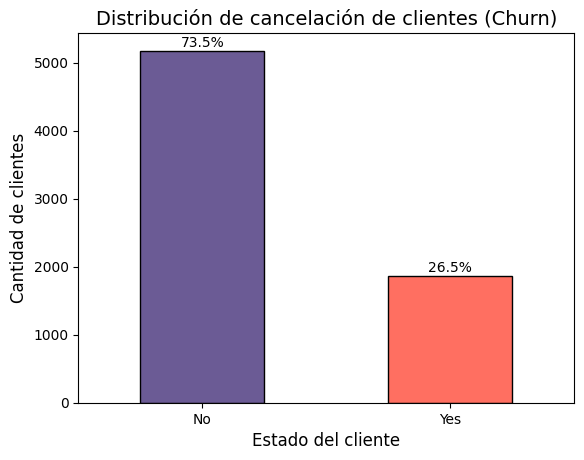

In [92]:
# Visualización gráfica.
ax = churn_counts.plot(kind="bar", color=colores, edgecolor='black')
plt.title("Distribución de cancelación de clientes (Churn)", fontsize=14)
plt.xlabel("Estado del cliente", fontsize=12)
plt.ylabel("Cantidad de clientes", fontsize=12)
plt.xticks(rotation=0)
for i, value in enumerate(churn_counts):
    porcentaje = churn_percent[i]
    ax.text(i, value + max(churn_counts)*0.01, f"{porcentaje:.1f}%", ha='center', fontsize=10)

plt.show()

In [93]:
#Visualización tabular de conteo y porcentaje.
df_churn_summary = pd.DataFrame({
    "Cantidad": churn_counts,
    "Porcentaje": churn_percent
})
df_churn_summary

,Cantidad,Porcentaje
Churn,,
No,5174,73.463013
Yes,1869,26.536987


## Recuento de evasión por variables categóricas.

In [94]:
# Lista de variables categóricas a analizar
variables_categoricas = [
    "customer.gender",
    "account.Contract",
    "account.PaymentMethod"
]

In [95]:
# Recorrer cada variable categórica.
for var in variables_categoricas:
# Agrupar.
    grupo = df.groupby(var)["Churn"].value_counts().unstack()

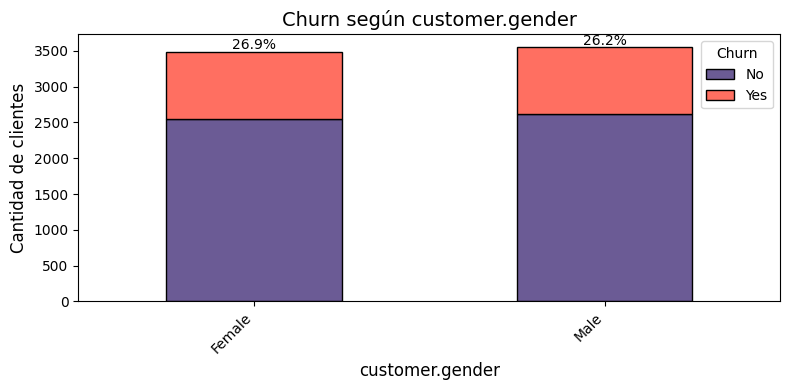

Distribución de Churn según customer.gender:



Churn,No,Yes,Total,%Yes
customer.gender,,,,
Female,2549,939,3488,26.920872
Male,2625,930,3555,26.160338


------------------------------------------------------------


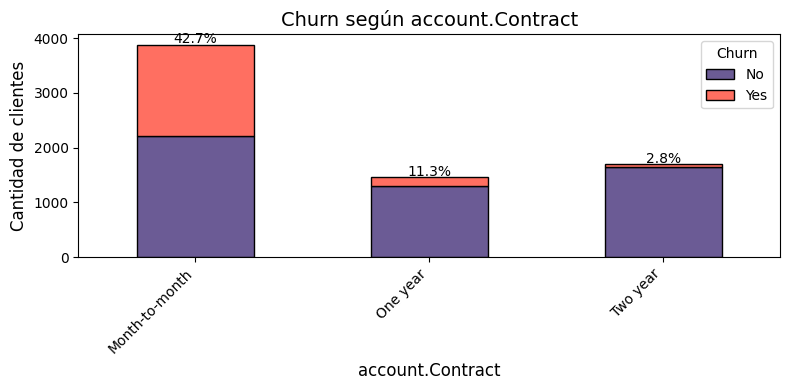

Distribución de Churn según account.Contract:



Churn,No,Yes,Total,%Yes
account.Contract,,,,
Month-to-month,2220,1655,3875,42.709677
One year,1307,166,1473,11.269518
Two year,1647,48,1695,2.831858


------------------------------------------------------------


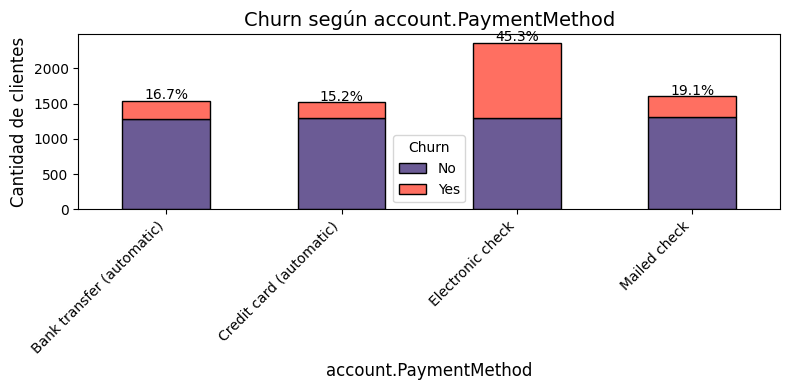

Distribución de Churn según account.PaymentMethod:



Churn,No,Yes,Total,%Yes
account.PaymentMethod,,,,
Bank transfer (automatic),1286,258,1544,16.709845
Credit card (automatic),1290,232,1522,15.243101
Electronic check,1294,1071,2365,45.285412
Mailed check,1304,308,1612,19.106700


------------------------------------------------------------


In [96]:
#Visualización gráfica.
for var in variables_categoricas:
    grupo = df.groupby([var,"Churn"]).size().unstack(fill_value=0)
    for col in ["No","Yes"]:
        if col not in grupo.columns:
            grupo[col]=0
    grupo=grupo[["No","Yes"]]

    grupo_porcentaje = grupo.div(grupo.sum(axis=1), axis=0)*100

    fig,ax=plt.subplots(figsize=(8,4))
    grupo.plot(kind="bar",stacked=True,color=colores,edgecolor='black',ax=ax)

    for i,idx in enumerate(grupo.index):
        total=grupo.loc[idx].sum()
        yes=grupo.loc[idx,"Yes"]
        porcentaje=yes/total*100
        ax.text(i,total+total*0.01,f"{porcentaje:.1f}%",ha='center',fontsize=10)

    plt.title(f"Churn según {var}",fontsize=14)
    plt.xlabel(var,fontsize=12)
    plt.ylabel("Cantidad de clientes",fontsize=12)
    plt.xticks(rotation=45,ha="right")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

    resumen=grupo.copy()
    resumen["Total"]=grupo.sum(axis=1)
    resumen["%Yes"]=grupo_porcentaje["Yes"]
    print(f"Distribución de Churn según {var}:\n")
    display(resumen)
    print("-"*60)

##Conteo de evasión por variables numéricas.

In [97]:
# Variables numéricas relevantes.
variables_numericas=["customer.tenure","account.Charges.Monthly","account.Charges.Total","Cuentas_Diarias"]

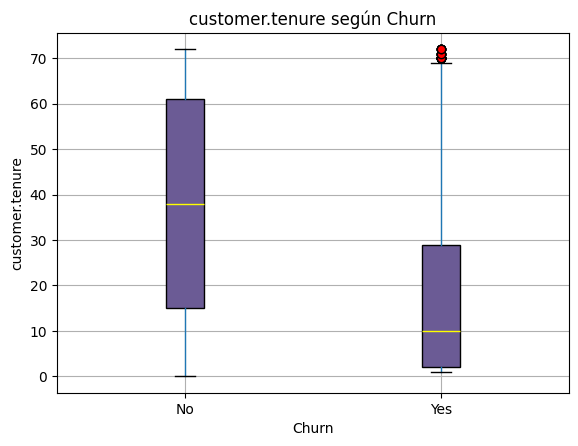

Resumen de customer.tenure por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Insight: Los clientes que cancelan suelen tener menor tiempo de permanencia que los que permanecen.

--------------------------------------------------


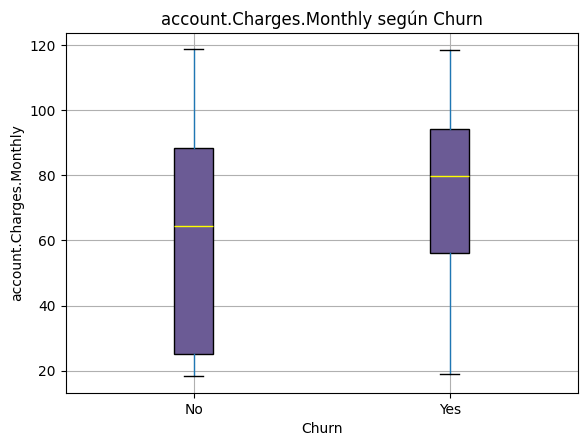

Resumen de account.Charges.Monthly por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Insight: Los clientes que cancelan presentan un cargo mensual ligeramente menor o intermedio.

--------------------------------------------------


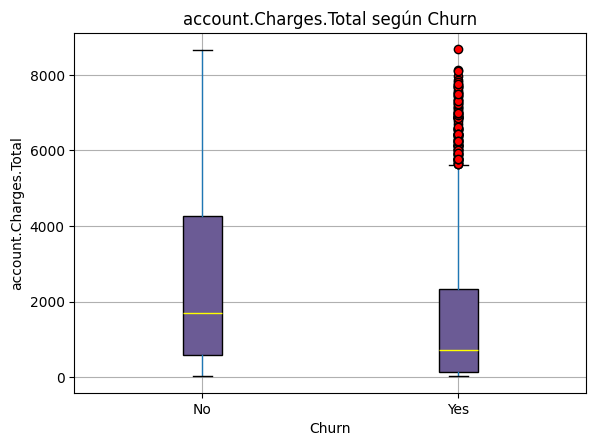

Resumen de account.Charges.Total por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


Insight: Los clientes que permanecen han pagado más en total, indicando mayor valor acumulado.

--------------------------------------------------


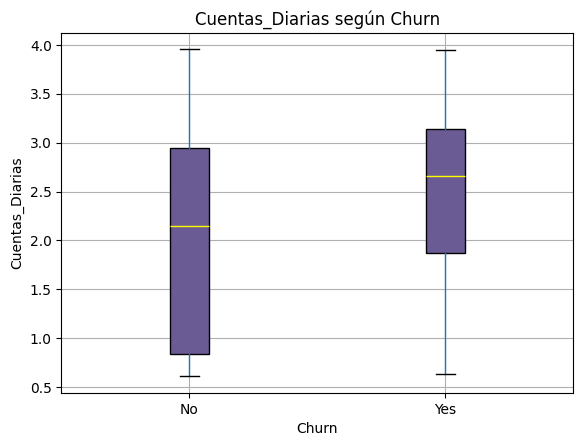

Resumen de Cuentas_Diarias por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2.042171,1.036422,0.608333,0.836667,2.1475,2.946667,3.958333
Yes,1869.0,2.481378,0.822202,0.628333,1.871667,2.6550,3.140000,3.945000


Insight: El gasto diario promedio es mayor en clientes que permanecen, mostrando consistencia en pagos.

--------------------------------------------------


In [98]:
for var in variables_numericas:
# Boxplot por Churn.
    df.boxplot(column=var, by="Churn", patch_artist=True,
               boxprops=dict(facecolor="#6B5B95"),
               medianprops=dict(color="yellow"),
               flierprops=dict(markerfacecolor="red", marker="o"))
    plt.title(f"{var} según Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(var)
    plt.show()

# Tabla descriptiva.
    print(f"Resumen de {var} por Churn:")
    display(df.groupby("Churn")[var].describe())

# Conclusión resumida.
    if var=="customer.tenure":
        print("Insight: Los clientes que cancelan suelen tener menor tiempo de permanencia que los que permanecen.\n")
    elif var=="account.Charges.Monthly":
        print("Insight: Los clientes que cancelan presentan un cargo mensual ligeramente menor o intermedio.\n")
    elif var=="account.Charges.Total":
        print("Insight: Los clientes que permanecen han pagado más en total, indicando mayor valor acumulado.\n")
    elif var=="Cuentas_Diarias":
        print("Insight: El gasto diario promedio es mayor en clientes que permanecen, mostrando consistencia en pagos.\n")

    print("-"*50)

#**Informe final.**

## 🔹 Introducción:
El objetivo de este análisis fue comprender los factores que influyen en la **evasión de clientes (Churn)** en Telecom X.  
Se analizaron tanto variables categóricas como numéricas para identificar patrones que puedan predecir la cancelación de clientes y guiar estrategias de retención.

## 🔹 Limpieza y tratamiento de datos.
- Se importó el dataset y el diccionario de variables desde GitHub.  
- Se eliminaron registros con `Churn` vacío.  
- Se convirtieron columnas numéricas que estaban como texto (`Charges.Total`) a tipo numérico.  
- Se verificaron duplicados, nulos y tipos de datos correctos.  
- Se creó la columna `Cuentas_Diarias` dividiendo `Charges.Monthly` entre 30, para analizar el gasto diario de los clientes.  

## 🔹 Análisis Exploratorio de Datos (EDA)

### 1️⃣ Variables categóricas
Se analizaron las variables:

- `customer.gender`  
- `account.Contract`  
- `account.PaymentMethod`  

**Gráficos:** barras apiladas con porcentajes de Churn sobre cada categoría.

**Principales hallazgos:**

- Los clientes con **contrato mensual** presentan mayor churn.  
- Clientes que usan **electronic check** tienen más cancelaciones.  
- No se observa diferencia significativa por **género**.  

### 2️⃣ Variables numéricas
Se analizaron:

- `customer.tenure`  
- `account.Charges.Monthly`  
- `account.Charges.Total`  
- `Cuentas_Diarias`  

**Gráficos:** boxplots por Churn y tablas descriptivas con media, mediana, desviación estándar, mínimos y máximos.

**Principales hallazgos:**

- Clientes que **cancelan** suelen tener menor **tenure** y **gasto diario menor**.  
- Clientes que **permanecen** muestran mayor permanencia y valor total pagado.  
- Las métricas de gasto y tiempo de contrato ayudan a identificar clientes con mayor riesgo de churn.  


## 🔹 Conclusiones e Insights
- La evasión de clientes es significativa y se concentra principalmente en:  
  - Clientes con **contrato mensual**  
  - Clientes con **menor tiempo de permanencia (tenure)**  
- El **valor del gasto diario y total** es un indicador de fidelidad: los clientes de mayor gasto tienden a permanecer.  
- El **método de pago** (`electronic check`) puede ser un factor de riesgo.

## 🔹 Recomendaciones
1. **Programas de fidelización para contratos mensuales** para incentivar renovación o upgrade a contratos anuales.  
2. **Alertas tempranas** para clientes con menor tenure y gasto diario bajo, ofreciendo incentivos o atención personalizada.  
3. **Monitoreo de métodos de pago** para identificar patrones de riesgo y ofrecer soporte o educación a clientes con `electronic check`.  
4. **Análisis continuo de métricas clave** como tenure y gasto diario para prevenir cancelaciones antes de que ocurran.  